# E-Commerce Customer Segmentation using RFM and Clustering

## 1. Import Libraries
## 2. Load Dataset
## 3. Data Understanding
## 4. Data Cleaning
## 5. Feature Engineering
## 6. Exploratory Data Analysis
## 7. RFM Analysis
## 8. Data Preprocessing
## 9. K-Means Clustering
## 10. Cluster Interpretation
## 11. Business Recommendations
## 12. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("data/ecommerce_data.csv")

df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4395 entries, 0 to 4394
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4395 non-null   object 
 1   StockCode    4395 non-null   object 
 2   Description  4328 non-null   object 
 3   Category     4395 non-null   object 
 4   Quantity     4395 non-null   int64  
 5   InvoiceDate  4395 non-null   object 
 6   UnitPrice    4395 non-null   float64
 7   CustomerID   4187 non-null   object 
 8   Country      4395 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 309.2+ KB


In [4]:
df.isnull().sum()

InvoiceNo        0
StockCode        0
Description     67
Category         0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     208
Country          0
dtype: int64

### Dataset Overview

- This dataset contains transaction-level purchase data from an e-commerce business.
- Each row represents a single product purchased in a customer invoice.
- The dataset includes product details, quantity purchased, price, customer ID, invoice information, and country.

### Column Description

- InvoiceNo → Unique invoice number for each transaction
- StockCode → Unique product code
- Description → Product name or description
- Category → Product category
- Quantity → Number of units purchased
- InvoiceDate → Date and time of purchase
- UnitPrice → Price per unit
- CustomerID → Unique customer identifier
- Country → Customer country

### Business Questions That Can Be Answered

- Which customers generate the most revenue?
- Which products sell the most?
- Which countries generate the highest sales?
- Which customers are inactive or loyal?
- How can customers be segmented for marketing campaigns?

### Business Questions That Cannot Be Answered

- Customer age or gender analysis cannot be performed.
- Profit analysis cannot be done because cost data is missing.
- Marketing campaign effectiveness cannot be measured because campaign data is unavailable.

In [5]:
print("Dataset Shape:", df.shape)

df.duplicated().sum()

Dataset Shape: (4395, 9)


np.int64(35)

In [6]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (4395, 9)
After removing duplicates: (4360, 9)


In [7]:
df.isnull().sum()

InvoiceNo        0
StockCode        0
Description     67
Category         0
Quantity         0
InvoiceDate      0
UnitPrice        0
CustomerID     206
Country          0
dtype: int64

In [8]:
print("Before removing missing CustomerID:", df.shape)

df = df.dropna(subset=['CustomerID'])

print("After removing missing CustomerID:", df.shape)

Before removing missing CustomerID: (4360, 9)
After removing missing CustomerID: (4154, 9)


In [9]:
df['Description'].isnull().sum()

np.int64(64)

In [10]:
print("Before removing missing descriptions:", df.shape)

df = df.dropna(subset=['Description'])

print("After removing missing descriptions:", df.shape)

Before removing missing descriptions: (4154, 9)
After removing missing descriptions: (4090, 9)


In [11]:
print("Zero or negative quantities:", (df['Quantity'] <= 0).sum())

print("Zero or negative prices:", (df['UnitPrice'] <= 0).sum())

Zero or negative quantities: 181
Zero or negative prices: 63


In [12]:
print("Before cleaning quantity and price:", df.shape)

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("After cleaning quantity and price:", df.shape)

Before cleaning quantity and price: (4090, 9)
After cleaning quantity and price: (3848, 9)


In [13]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Category        object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Category               object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

In [15]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Category,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,INV500000,P1022,Dark Chocolate Box,Grocery,1,2025-01-19 17:04:00,468.04,C10555,EIRE,468.04
1,INV500000,P1030,Sports Socks Pack,Apparel,1,2025-01-19 17:04:00,248.30,C10555,EIRE,248.30
2,INV500001,P1006,Wireless Mouse,Electronics,5,2025-10-17 18:50:00,729.12,C10422,India,3645.60
3,INV500002,P1010,Protein Shaker,Fitness,2,2025-01-05 22:51:00,329.60,C10262,Netherlands,659.20
4,INV500002,P1022,Dark Chocolate Box,Grocery,1,2025-01-05 22:51:00,526.21,C10262,Netherlands,526.21


### Data Cleaning Summary

- Removed duplicate records
- Removed rows with missing CustomerID
- Removed rows with missing product descriptions
- Removed rows with zero or negative quantities
- Removed rows with zero or negative unit prices
- Converted InvoiceDate to datetime format
- Created Revenue column for sales analysis

Final cleaned dataset contains 3848 rows.

In [16]:
customer_features = df.groupby('CustomerID').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'StockCode': 'nunique',
    'Country': 'first'
}).reset_index()

In [17]:
customer_features.columns = [
    'CustomerID',
    'TotalRevenue',
    'TotalPurchases',
    'TotalQuantity',
    'UniqueProducts',
    'Country'
]

customer_features['AverageOrderValue'] = (
    customer_features['TotalRevenue'] / customer_features['TotalPurchases']
)

customer_features.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue
0,C10001,22885.81,3,63,8,India,7628.603333
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000
3,C10005,14154.57,2,17,7,Germany,7077.285000
4,C10006,27389.29,3,27,8,India,9129.763333


In [18]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,C10001,117,3,22885.81
1,C10003,33,1,12061.04
2,C10004,40,2,10579.97
3,C10005,297,2,14154.57
4,C10006,31,3,27389.29


In [19]:
customer_data = pd.merge(customer_features, rfm, on='CustomerID')

customer_data.head()

,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue,Recency,Frequency,Monetary
0,C10001,22885.81,3,63,8,India,7628.603333,117,3,22885.81
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000,33,1,12061.04
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000,40,2,10579.97
3,C10005,14154.57,2,17,7,Germany,7077.285000,297,2,14154.57
4,C10006,27389.29,3,27,8,India,9129.763333,31,3,27389.29


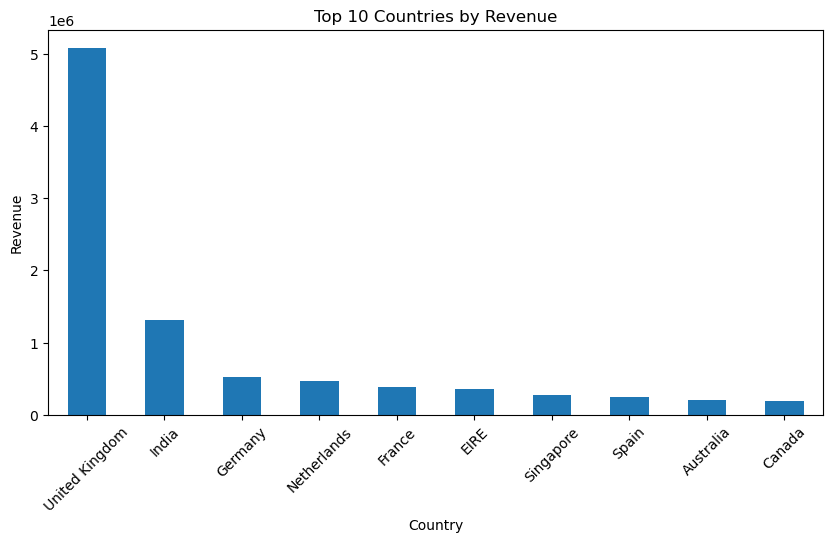

In [20]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_countries.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

### Interpretation
The chart shows the countries generating the highest revenue for the business. These countries contribute significantly to overall sales and may be important targets for marketing and customer retention strategies.

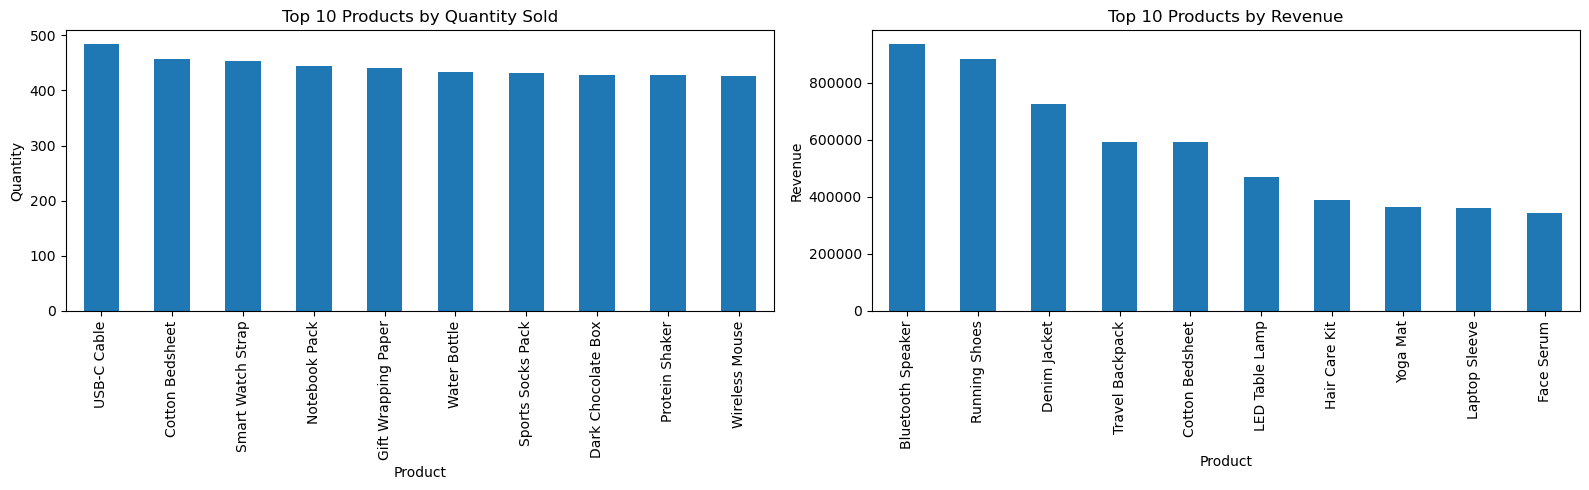

In [21]:
top_products_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16,5))

top_products_quantity.plot(kind='bar', ax=axes[0])
axes[0].set_title('Top 10 Products by Quantity Sold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Quantity')

top_products_revenue.plot(kind='bar', ax=axes[1])
axes[1].set_title('Top 10 Products by Revenue')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

### Interpretation
Some products are purchased frequently in high quantities, while others generate higher revenue due to higher prices. These insights help identify bestselling and high-profit product categories.

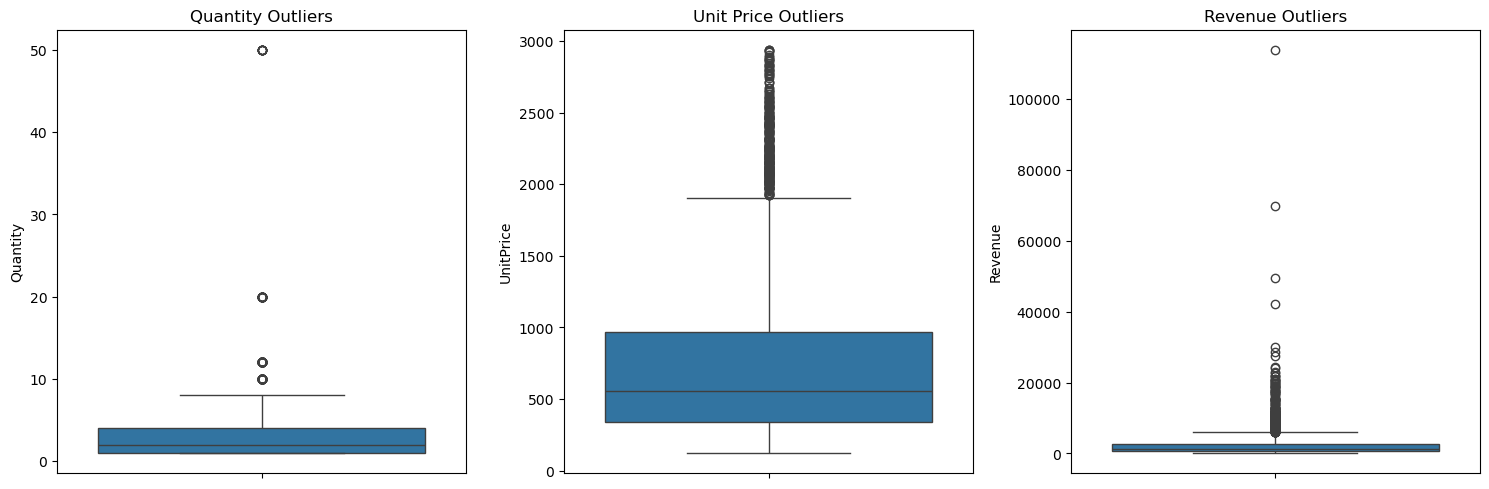

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.boxplot(y=df['Quantity'], ax=axes[0])
axes[0].set_title('Quantity Outliers')

sns.boxplot(y=df['UnitPrice'], ax=axes[1])
axes[1].set_title('Unit Price Outliers')

sns.boxplot(y=df['Revenue'], ax=axes[2])
axes[2].set_title('Revenue Outliers')

plt.tight_layout()
plt.show()

### Interpretation
The boxplots indicate the presence of outliers in quantity, unit price, and revenue. These extreme values may represent bulk purchases or high-value transactions that are important for customer segmentation.

In [23]:
rfm_data = customer_data[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_data)

rfm_scaled[:5]

array([[-0.0800508 ,  0.88455416,  0.7537231 ],
       [-1.02072989, -0.93532917, -0.10768099],
       [-0.94233996, -0.02538751, -0.22554028],
       [ 1.93569011, -0.02538751,  0.05891611],
       [-1.04312701,  0.88455416,  1.11209709]])

c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

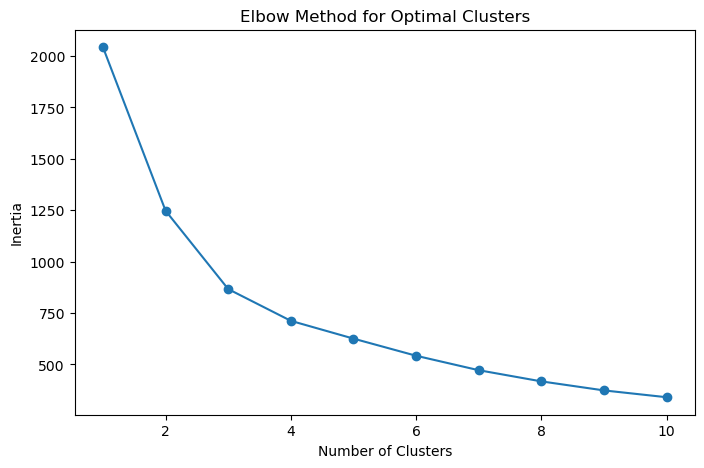

In [24]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_data['Cluster'] = kmeans.fit_predict(rfm_scaled)

customer_data.head()

c:\Users\sathv\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,CustomerID,TotalRevenue,TotalPurchases,TotalQuantity,UniqueProducts,Country,AverageOrderValue,Recency,Frequency,Monetary,Cluster
0,C10001,22885.81,3,63,8,India,7628.603333,117,3,22885.81,1
1,C10003,12061.04,1,10,3,United Kingdom,12061.040000,33,1,12061.04,0
2,C10004,10579.97,2,16,5,United Kingdom,5289.985000,40,2,10579.97,0
3,C10005,14154.57,2,17,7,Germany,7077.285000,297,2,14154.57,2
4,C10006,27389.29,3,27,8,India,9129.763333,31,3,27389.29,1


In [26]:
cluster_summary = customer_data.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,66.761745,1.805369,9370.575973
1,75.277778,3.534722,30601.338750
2,225.146444,1.397490,8100.624435


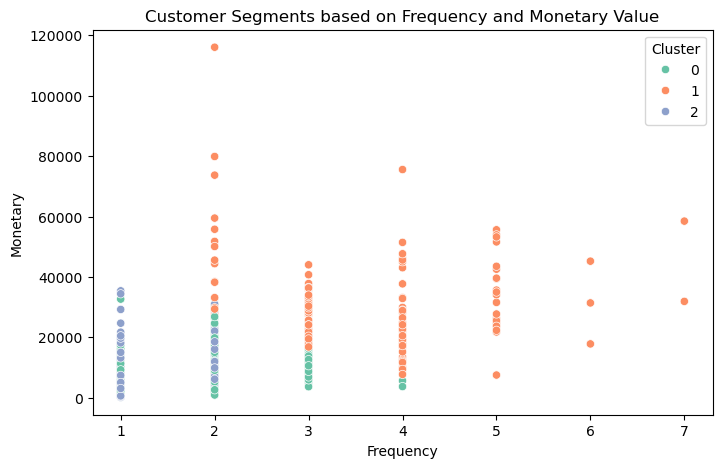

In [27]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=customer_data,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments based on Frequency and Monetary Value')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

## Cluster Interpretation

### Cluster 0 - Regular Customers
- Moderate recency and moderate spending
- Purchase occasionally with average monetary contribution
- Represents stable customers with potential for growth
- Business Value:
  These customers can be encouraged to purchase more frequently using personalized recommendations and promotional offers.

### Cluster 1 - High Value Loyal Customers
- High frequency and highest monetary value
- Customers purchase frequently and contribute significant revenue
- Represents the most valuable customer segment
- Business Value:
  These customers are critical for business profitability and should be retained through loyalty rewards, premium offers, and exclusive benefits.

### Cluster 2 - Inactive or At-Risk Customers
- High recency with low frequency and lower spending
- Customers have not purchased recently
- Represents customers at risk of churn
- Business Value:
  These customers should be targeted using re-engagement campaigns, discounts, and reminder emails to encourage repeat purchases.

# Business Recommendations

- Provide loyalty rewards and exclusive discounts for high-value loyal customers to improve retention.
- Launch personalized re-engagement campaigns for inactive customers with high recency values.
- Offer bundle deals and product recommendations to regular customers to increase purchase frequency.
- Focus marketing campaigns on countries generating the highest revenue.
- Promote high-performing products through targeted advertising and seasonal campaigns.
- Monitor customers with declining activity and provide special offers before they become inactive.
- Use customer segmentation to personalize email marketing and improve campaign effectiveness.

In [28]:
customer_data.to_csv("outputs/customer_segments.csv", index=False)

# Conclusion

This project analyzed e-commerce customer transaction data to understand customer purchasing behavior and identify meaningful customer segments using RFM analysis and K-Means clustering.

The analysis revealed different customer groups such as high-value loyal customers, regular customers, and inactive customers. These insights can help the company design targeted marketing campaigns, improve customer retention, and increase overall business revenue through personalized strategies.